In [29]:
from numpy._core.fromnumeric import shape
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
customers = pd.read_csv("/content/olist_customers_dataset.csv")
geolocation = pd.read_csv("/content/olist_geolocation_dataset.csv")
items = pd.read_csv("/content/olist_order_items_dataset.csv")
payments = pd.read_csv("/content/olist_order_payments_dataset.csv")
reviews = pd.read_csv("/content/olist_order_reviews_dataset.csv")
orders = pd.read_csv("/content/olist_orders_dataset.csv")
products = pd.read_csv("/content/olist_products_dataset.csv")
sellers = pd.read_csv("/content/olist_sellers_dataset.csv")
product_translation = pd.read_csv("/content/product_category_name_translation.csv")



In [31]:
# Explore the data for null values, duplicates and shape of the datas
labels = {'Customers' : customers,
               'Geolocation' : geolocation,
               'Items' : items,
               'Payments' : payments,
               'Reviews' : reviews,
               'Orders' : orders,
               'Products' : products,
               'Sellers' : sellers,
               'Product_name_translation' : product_translation
}
for name,label in labels.items():
  print(f"------{name}-------")
  print(f"\n{name}.info:")
  print(label.info())
  print(f"\n{name}.shape: {label.shape}")
  print(f"\n{name}.columns: {label.columns.tolist()}")
  print(f"\n{name}.isnull().sum():\n {label.isnull().sum()}")
  print(f"\n{name}.duplicated().sum(): {label.duplicated().sum()}\n")
  print("="*60)

------Customers-------

Customers.info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

Customers.shape: (99441, 5)

Customers.columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Customers.isnull().sum():
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Customers.duplicated().sum(): 0

------Geolocation-------

Geolocation.info:


In [32]:
# for geolocation there are huge duplicates present in the dataset, inspect them
geo_duplicate = geolocation[geolocation.duplicated(subset = ["geolocation_zip_code_prefix"],keep = False)]
geo_duplicate = geo_duplicate.sort_values(by = ["geolocation_zip_code_prefix","geolocation_city"])
print(geo_duplicate.head(20))

# One row per ZIP prefix: use this table when joining with customers / sellers
geo_group = geolocation.groupby("geolocation_zip_code_prefix", as_index=False).agg({
    "geolocation_lat": "median",
    "geolocation_lng": "median",
    "geolocation_city": lambda x: x.mode().iloc[0],
    "geolocation_state": lambda x: x.mode().iloc[0]
})

# Check the result
print("Raw rows:", len(geolocation))
print("Rows after grouping:", len(geo_group))
print("Duplicate ZIPs left:", geo_group["geolocation_zip_code_prefix"].duplicated().sum())


      geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
99                           1001       -23.549292       -46.633559   
206                          1001       -23.550498       -46.634338   
235                          1001       -23.550642       -46.634410   
299                          1001       -23.549698       -46.633909   
326                          1001       -23.551427       -46.634074   
429                          1001       -23.550498       -46.634338   
519                          1001       -23.551337       -46.634027   
583                          1001       -23.551337       -46.634027   
596                          1001       -23.550498       -46.634338   
639                          1001       -23.550498       -46.634338   
771                          1001       -23.550498       -46.634338   
818                          1001       -23.551337       -46.634027   
851                          1001       -23.549825       -46.633970   
864   

Geolocation contains nearly 1 million coordinate records because each ZIP-code prefix has many sample points. These are not exact customer addresses, so the raw table is kept unchanged in geolocation. A second table, geo_group, holds one row per ZIP prefix (median latitude/longitude, most common city/state). geo_group is used for any join with customers or sellers, because joining the raw table would repeat each order many times.

In [33]:
# Reviews

# Keep missing comments empty, and add a True/False column instead
reviews["has_comment"] = reviews["review_comment_message"].notna()

# Convert the time in a default datetime format
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"], errors="coerce")

# Days the customer took to answer the survey (renamed from response_time)
reviews["survey_answer_days"] = (reviews["review_answer_timestamp"] - reviews["review_creation_date"]).dt.total_seconds() / 86400
print(reviews["survey_answer_days"].describe())

# Review score validation
reviews_score_count = reviews.groupby("review_score", as_index=False).agg(review_count=("review_id", "count"))
print(reviews_score_count)
print("Review scores:", sorted(reviews["review_score"].dropna().unique()))

# Check duplicates
print("Duplicate review_id:", reviews["review_id"].duplicated().sum())
print("Orders with more than 1 review:", (reviews.groupby("order_id").size() > 1).sum())

# Keep only the latest review for each order
reviews_one = reviews.sort_values("review_answer_timestamp").drop_duplicates(subset="order_id", keep="last")
print("reviews_one shape:", reviews_one.shape)

count    99224.000000
mean         3.148993
std          9.890049
min          0.089225
25%          1.004870
50%          1.674948
75%          3.103565
max        518.699213
Name: survey_answer_days, dtype: float64
   review_score  review_count
0             1         11424
1             2          3151
2             3          8179
3             4         19142
4             5         57328
Review scores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Duplicate review_id: 814
Orders with more than 1 review: 547
reviews_one shape: (98673, 9)


**Reviews: Data Cleaning**

*   Missing review titles and comments were **kept as empty values**, not replaced with placeholder text such as "No Title". Placeholders would be counted as real text in any later text analysis. A new True/False column, `has_comment`, shows whether the customer wrote a comment.
*   `review_creation_date` and `review_answer_timestamp` were converted to datetime format.
*   `survey_answer_days` was calculated as the time between the survey being sent and the customer answering, in days. It measures the **customer's** answering time, not the company's response time.
*   Review scores were counted and checked against the valid 1-5 range. The score distribution shows 57328 are 5 stars, and 11424 are 1 star.
*   Duplicate checks found 814 duplicate `review_id` values and 547 orders with more than one review.
*   Because an order with two reviews would be counted twice in a merge, `reviews_one` was created, keeping only the **latest review for each order**. It has 98673 rows.

In [34]:
# Orders

# Convert date columns to datetime format
date_time = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']
for date in date_time:
  orders[date] = pd.to_datetime(orders[date],errors="coerce")

missing_dates_by_status = orders.groupby("order_status").agg({
  "order_approved_at": lambda x: x.isnull().sum(),
  "order_delivered_carrier_date": lambda x: x.isnull().sum(),
  "order_delivered_customer_date": lambda x: x.isnull().sum()
})
print("Missing values:\n",missing_dates_by_status)

# 1. approval_time (ordered_time : Purchase → Approval)
orders["ordered_time"] = (orders["order_approved_at"] - orders["order_purchase_timestamp"]).dt.total_seconds()/86400

# 2. seller_processing_time (shipped_time : Approval → Carrier)
orders["shipped_time"] = (orders["order_delivered_carrier_date"] - orders["order_approved_at"]).dt.total_seconds()/86400

# 3. carrier_transit_time (out_for_delivery_time : Carrier → Customer)
orders["out_for_delivery_time"] = (orders["order_delivered_customer_date"] - orders["order_delivered_carrier_date"]).dt.total_seconds()/86400

# 4. total_delivery_time (delivered_time : Purchase → Customer)
orders["delivered_time"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.total_seconds()/86400

# 5. delivery_delay: compare DATES only, because the estimate is a date (no time)
orders["delay_time"] = (orders["order_delivered_customer_date"].dt.normalize() - orders["order_estimated_delivery_date"].dt.normalize()).dt.days

# Investigate negative seller-processing times.
# These occur when the carrier timestamp is earlier than the approval timestamp.
print("\nOrders with negative seller-processing time:\n")
print(orders[orders["shipped_time"] < 0][["order_id","order_status",
            "order_approved_at","order_delivered_carrier_date",
            "shipped_time"]]
)

# Investigate unusually long carrier-to-customer delivery times.
print("\nOrders with carrier transit time greater than 100 days:\n")
print(orders[orders["out_for_delivery_time"] > 100][["order_id","order_status",
            "order_delivered_carrier_date","order_delivered_customer_date",
            "out_for_delivery_time"]]
)

# Create a delivery-performance category

orders["delivery_status"] = "Unknown"

orders.loc[orders["delay_time"] < 0, "delivery_status"] = "Early"

orders.loc[orders["delay_time"] == 0, "delivery_status"] = "On Time"

orders.loc[orders["delay_time"] > 0, "delivery_status"] = "Late"

# Inspect delivery status
print("\nDelivery status:\n")
print(orders["delivery_status"].value_counts(dropna=False))

# Check missing values in calculated columns
delivery_columns = [
    "ordered_time",
    "shipped_time",
    "out_for_delivery_time",
    "delivered_time",
    "delay_time"
]

print("\nChecking null values:\n")
print(orders[delivery_columns].isnull().sum())

# Check the calculated metrics
print("\nChecking descriptive statistics:\n")
print(orders[delivery_columns].describe())


Missing values:
               order_approved_at  order_delivered_carrier_date  \
order_status                                                    
approved                      0                             2   
canceled                    141                           550   
created                       5                             5   
delivered                    14                             2   
invoiced                      0                           314   
processing                    0                           301   
shipped                       0                             0   
unavailable                   0                           609   

              order_delivered_customer_date  
order_status                                 
approved                                  2  
canceled                                619  
created                                   5  
delivered                                 8  
invoiced                                314  
processing

**Orders: Timestamps and Delivery Metrics**

*   The five order timestamp columns were converted to datetime format. Invalid values became missing values.
*   Missing timestamps were counted by order status. Orders that were canceled, unavailable, invoiced, processing or shipped naturally have no customer-delivery date, so most missing values are expected and are **not** errors.
*   Five time metrics were created, all measured in **days** (including fractions of a day):
    *   `ordered_time`: purchase → approval
    *   `shipped_time`: approval → carrier pickup (seller processing)
    *   `out_for_delivery_time`: carrier pickup → customer
    *   `delivered_time`: purchase → customer (total delivery time)
    *   `delay_time`: actual delivery date minus estimated delivery date
*   Time metrics use exact days instead of whole days, so a gap of a few hours is not rounded into a full day. `delay_time` compares **dates only**, because the estimated delivery is a date without a time.
*   Negative `shipped_time` values (carrier date earlier than approval date) and very long `out_for_delivery_time` values (over 100 days) were investigated, not removed. They are treated as **anomalies**, not proven errors. For example, a seller may ship before a payment is approved.
*   Orders were classified as **Early**, **On Time** or **Late** . Orders without a customer-delivery date stay as **Unknown**.
*   Descriptive statistics were checked for every metric to understand its distribution and find unusual values: mean of `delay_time` is approximately 12 days

In [35]:
# Negative seller-processing time (carrier date earlier than approval date)
negative_shipped = orders[orders["shipped_time"] < 0].copy()
print("Negative shipped time (days):")
print(negative_shipped["shipped_time"].describe())

# The same values in hours (many are only a few hours)
print("\nSame values in hours:")
print((negative_shipped["shipped_time"] * 24).describe())

# Negative out-for-delivery time
negative_delivery = orders[orders["out_for_delivery_time"] < 0]
print("\nNegative out-for-delivery time:")
print(negative_delivery["out_for_delivery_time"].describe())

# Extremely long carrier transit
long_delivery = orders[orders["out_for_delivery_time"] > 100]
print("\nLong time for delivery:")
print(long_delivery["out_for_delivery_time"].describe())

# Month concentration of negative values
negative_shipped["approval_month"] = negative_shipped["order_approved_at"].dt.to_period("M")
print("\nNegative shipped times by approval month:")
print(negative_shipped["approval_month"].value_counts().sort_index())

# Reconcile the counts
print("\nNegative:", orders["shipped_time"].lt(0).sum())
print("Zero:", orders["shipped_time"].eq(0).sum())
print("Missing:", orders["shipped_time"].isna().sum())

# A seperate Dataset for processing-time analysis (>= 0 automatically removes missing values too)
valid_shipped = orders[orders["shipped_time"] >= 0].copy()
print("Shape of valid_shipped:", valid_shipped.shape)

Negative shipped time (days):
count    1359.000000
mean       -1.031333
std         4.804491
min      -171.219005
25%        -1.081528
50%        -0.715324
75%        -0.058976
max        -0.000243
Name: shipped_time, dtype: float64

Same values in hours:
count    1359.000000
mean      -24.751987
std       115.307793
min     -4109.256111
25%       -25.956667
50%       -17.167778
75%        -1.415417
max        -0.005833
Name: shipped_time, dtype: float64

Negative out-for-delivery time:
count    23.000000
mean     -3.268964
std       3.721170
min     -16.096169
25%      -5.364959
50%      -1.661019
75%      -0.972431
max      -0.016181
Name: out_for_delivery_time, dtype: float64

Long time for delivery:
count     56.000000
mean     146.094533
std       31.737812
min      100.893773
25%      121.600888
50%      138.748999
75%      174.285113
max      205.190972
Name: out_for_delivery_time, dtype: float64

Negative shipped times by approval month:
approval_month
2017-03      1
2017-04   

**Seller Processing & Delivery Time: Data Quality Checks**

*   **Negative `shipped_time`:** 1359 orders have a carrier pickup date earlier than the approval date. The values are shown in days and in hours. The hours view shows that  these gaps are only a small timing differences, not large errors.
*   **Why this may be real:** a seller can hand the parcel to the carrier before the payment is approved, for example with a bank-slip payment. These records are therefore called **anomalous (possibly process-related)**, not "impossible".
*   **Concentration in time:** the negative values are concentrated in April and july 2018, with the highest counts in july (565 records) and april (393 records). This suggests a period-specific recording or process pattern.
*   **Negative `out_for_delivery_time`:** 1359 orders show the customer receiving the parcel before the carrier pickup date. This is logically inconsistent and is flagged as a data-quality issue.
*   **Very long transit:** 56 orders have a carrier-to-customer time above 100 days (mean ~146 days, maximum ~205 days). They are kept for now and investigated separately in the delivery-time cells.
*   **Count check:** negative + zero + missing + non-negative values add up to the total number of orders, which confirms no records were lost.
*   **`valid_shipped`:** a separate dataset with `shipped_time` of 0 or more (96285 rows out of 99441 orders). Missing values are excluded automatically. It is used only for seller-processing analysis. The original `orders` table keeps all records for data-quality review.

In [37]:
# Delivered orders that have a purchase date and a customer-delivery date
valid_delivery = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_purchase_timestamp"].notna()) &
    (orders["order_delivered_customer_date"].notna())
].copy()
print("Valid delivered orders:", len(valid_delivery))

# Total delivery time: Purchase → Customer (in days)
valid_delivery["delivery_time"] = (valid_delivery["order_delivered_customer_date"]
                                   - valid_delivery["order_purchase_timestamp"]).dt.total_seconds() / 86400

# Delivery before purchase is truly impossible
neg_delivery_time = (valid_delivery["delivery_time"] < 0).sum()
print("Negative delivery times:", neg_delivery_time)

Valid delivered orders: 96470
Negative delivery times: 0


**Valid Delivery Dataset**

*   `valid_delivery` was created from orders with status **delivered** that have both a **purchase timestamp** and a **customer-delivery timestamp**. These are the only two dates needed to measure total delivery time. This gave 96470 orders.
*   Orders that were only missing an approval date or carrier date are **kept**, because those dates are not used in this calculation.
*   `delivery_time` is the time from **purchase to customer delivery**, in days (including fractions of a day). This is what the customer experiences, and the estimated delivery date is also based on the purchase date.
*   The check for negative delivery times found 0 orders.
*   Only delivered orders are included. Canceled, unavailable and still-shipping orders are left out, so the results describe **completed deliveries only**.

In [38]:
# For delivery-time analysis, exclude negative values
valid_delivery_time = valid_delivery[valid_delivery["delivery_time"] >= 0].copy()

print("Original valid deliveries:", len(valid_delivery))
print("Valid delivery times:", len(valid_delivery_time))
print("Removed negative times:", (valid_delivery["delivery_time"] < 0).sum())
print("\nvalid delivery time analysis:\n",valid_delivery_time["delivery_time"].describe())

# Inspect long deliveries
long_delivery = valid_delivery_time[valid_delivery_time["delivery_time"] > 60].copy()

print("\nOrders with delivery time > 60 days:", len(long_delivery))

print(long_delivery[[
            "order_id",
            "order_status",
            "order_approved_at",
            "order_delivered_carrier_date",
            "order_delivered_customer_date",
            "delivery_time"
        ]].sort_values("delivery_time", ascending=False).head(10).to_string(index=False))

# Check how these >60-day orders are distributed by delivery date
print("\nDelivery date distibution:\n",long_delivery["order_delivered_customer_date"].dt.to_period("M").value_counts().sort_index())

# Check whether a few specific dates account for many of these extreme deliveries
print("\n",long_delivery["order_delivered_customer_date"].dt.date.value_counts().head(10))

Original valid deliveries: 96470
Valid delivery times: 96470
Removed negative times: 0

valid delivery time analysis:
 count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_time, dtype: float64

Orders with delivery time > 60 days: 306
                        order_id order_status   order_approved_at order_delivered_carrier_date order_delivered_customer_date  delivery_time
ca07593549f1816d26a572e06dc1eab6    delivered 2017-02-23 02:35:15          2017-03-08 13:47:46           2017-09-19 14:36:39     209.628611
1b3190b2dfa9d789e1f14c05b647a14a    delivered 2018-02-23 15:16:14          2018-02-26 18:49:07           2018-09-19 23:24:07     208.351759
440d0d17af552815d15a9e41abe49359    delivered 2017-03-09 01:11:33          2017-03-15 13:00:08           2017-09-19 15:12:50     195.634016
2fb597c2f772eca01b1f5c561bf6cc7b    delivered 2017-03-08 18:09:02  

**Delivery-Time Validation and Long Deliveries**

*   `valid_delivery_time` keeps orders with a delivery time of 0 days or more.
*   Delivery time (purchase to customer) has a mean of ~12 days, a median of ~9 days, Q1 of ~6, Q3 of ~15 and a maximum of ~209 days. The mean is higher than the median because a few very slow orders pull it up.
*   306 orders took more than 60 days. This is a small group, but it makes the long tail of the distribution.
*   The delivery dates of these slow orders were checked by month and by day.


In [ ]:
# Investigate the orders delivered on 2017-09-19
sep19_orders = long_delivery[
    long_delivery["order_delivered_customer_date"].dt.date
    == pd.Timestamp("2017-09-19").date()
].copy()

print("\nOrders delivered on 2017-09-19:", len(sep19_orders))

# Distinguish genuine delays from suspicious timestamps
print("\nDatas of sep19:\n")
print(sep19_orders[[
            "order_id",
            "order_approved_at",
            "order_delivered_carrier_date",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
            "delivery_time"
        ]].sort_values("delivery_time", ascending=False).to_string(index=False))

# Check the order status distribution
print("\nDistribution:\n",sep19_orders["order_status"].value_counts())

# Check the order purchase timestamp
print("\nOrder purchased timestamp:\n")
print(sep19_orders[[
            "order_id",
            "order_purchase_timestamp",
            "order_approved_at",
            "order_delivered_carrier_date",
            "order_delivered_customer_date",
            "order_estimated_delivery_date"
        ]].to_string(index=False))


Orders delivered on 2017-09-19: 27

Datas of sep19:

                        order_id   order_approved_at order_delivered_carrier_date order_delivered_customer_date order_estimated_delivery_date  delivery_time
ca07593549f1816d26a572e06dc1eab6 2017-02-23 02:35:15          2017-03-08 13:47:46           2017-09-19 14:36:39                    2017-03-22            208
0f4519c5f1c541ddec9f21b3bddd533a 2017-03-09 13:26:57          2017-03-22 05:28:14           2017-09-19 14:38:21                    2017-04-11            194
440d0d17af552815d15a9e41abe49359 2017-03-09 01:11:33          2017-03-15 13:00:08           2017-09-19 15:12:50                    2017-04-07            194
2fb597c2f772eca01b1f5c561bf6cc7b 2017-03-08 18:09:02          2017-03-13 08:54:02           2017-09-19 14:33:17                    2017-04-17            194
285ab9426d6982034523a855f55a885e 2017-03-08 22:47:40          2017-03-09 08:53:20           2017-09-19 14:00:04                    2017-04-06            194
2fe3

**Investigation of the sep 19 Delivery Records**

*   27 orders with delivery times over 60 days were delivered on sep 19.
*   All of these orders have the status delivered, with purchase, approval, carrier, customer and estimated dates present. The dates are in a logical order.
*   Many of them were delivered far after their estimated dates.
*   Orders placed in different months all being delivered on the **same day** looks like a system or batch recording event. A valid date order does not prove the delay was real, so these records **may be a recording artefact**.
*   They were kept in the data, and the next cell checks how much they change the results.

Before removing Sep 19 orders:
count    96394.000000
mean        11.650891
std          9.515924
min          0.000000
25%          6.000000
50%          9.000000
75%         15.000000
max        208.000000
Name: delivery_time, dtype: float64

After removing Sep 19 orders:
count    96112.000000
mean        11.606771
std          9.188153
min          0.000000
25%          6.000000
50%          9.000000
75%         15.000000
max        208.000000
Name: delivery_time, dtype: float64
0.900     22.0
0.950     28.0
0.990     45.0
0.995     53.0
1.000    208.0
Name: delivery_time, dtype: float64
Delivery time > 30 days: 3906
Delivery time > 45 days: 923
Delivery time > 53 days: 470
Delivery time > 60 days: 282
Delivery time > 90 days: 76


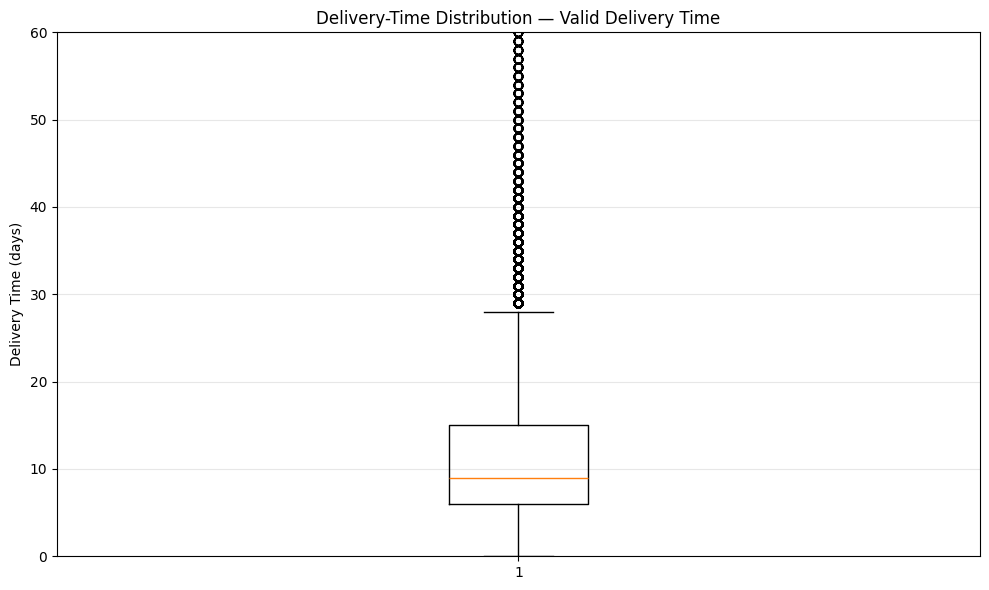

In [ ]:
# Compare delivery statistics with and without these orders
print("Before removing Sep 19 orders:")
print(valid_delivery_time["delivery_time"].describe())

valid_delivery_time_no_sep19 = valid_delivery_time[
    valid_delivery_time["order_delivered_customer_date"].dt.date
    != pd.Timestamp("2017-09-19").date()
].copy()

print("\nAfter removing Sep 19 orders:")
print(valid_delivery_time_no_sep19["delivery_time"].describe())

# Identify all extreme delivery times
print(valid_delivery_time["delivery_time"].quantile([0.90, 0.95, 0.99, 0.995, 1.00]))

# Count how many orders fall into progressively higher ranges
print("Delivery time > 30 days:", (valid_delivery_time["delivery_time"] > 30).sum())
print("Delivery time > 45 days:", (valid_delivery_time["delivery_time"] > 45).sum())
print("Delivery time > 53 days:", (valid_delivery_time["delivery_time"] > 53).sum())
print("Delivery time > 60 days:", (valid_delivery_time["delivery_time"] > 60).sum())
print("Delivery time > 90 days:", (valid_delivery_time["delivery_time"] > 90).sum())

# Boxplot for valid_delivery_time
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.boxplot(
    valid_delivery_time["delivery_time"],
    vert=True
)

plt.ylim(0, 60)     # Maximum delivery_time is 208 days, the extreme values can make the box itself look very compressed.
                    # So, show the main distribution up to 60 days

plt.ylabel("Delivery Time (days)")
plt.title("Delivery-Time Distribution — Valid Delivery Time")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("valid_delivery_time_boxplot.png", dpi=300)
plt.show()

**Effect of the sep 19 Orders and Spread of Delivery Times**

*   The statistics were compared with and without the 27 orders delivered on sep 19. The mean changed from 11.65 to 11.60 days. "The change is small, so these orders do not affect the overall results much."
*   The 90th, 95th, 99th and 99.5th percentiles are 22, 28, 45 and 53 days, while the maximum is 208 days.
*   3906 orders took more than 30 days, 282 more than 60 days and 76 more than 90 days. The long-delivery group is small but real.
*   The boxplot shows only 0 to 60 days. Without this limit, the few extreme values would squash the box and make the main distribution hard to see.

In [ ]:
# Check whether 76 extreme delays spread naturally, or concentrated on a few suspicious dates
extreme_delivery = valid_delivery_time[valid_delivery_time["delivery_time"] > 90].copy()

print("Orders with delivery time > 90 days:", len(extreme_delivery))

print(extreme_delivery["order_delivered_customer_date"].dt.date.value_counts().head(15))

# Inspect the 76 extreme orders against their estimated dates
extreme_delivery["days_late"] = (
    extreme_delivery["order_delivered_customer_date"].dt.normalize()
    - extreme_delivery["order_estimated_delivery_date"].dt.normalize()
).dt.days

print(extreme_delivery["days_late"].describe())

print(extreme_delivery[[
            "order_id",
            "order_approved_at",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
            "delivery_time",
            "days_late"
        ]].sort_values("days_late", ascending=False).head(15).to_string(index=False))



Orders with delivery time > 90 days: 76
order_delivered_customer_date
2017-09-19    24
2018-04-19     4
2018-05-30     2
2017-04-26     2
2018-06-19     1
2018-05-18     1
2018-02-27     1
2018-05-07     1
2018-05-23     1
2018-07-13     1
2018-07-26     1
2018-08-20     1
2018-10-17     1
2018-03-27     1
2017-06-14     1
Name: count, dtype: int64
count     76.000000
mean     107.671053
std       35.807779
min       51.000000
25%       77.750000
50%      104.000000
75%      134.750000
max      188.000000
Name: days_late, dtype: float64
                        order_id   order_approved_at order_delivered_customer_date order_estimated_delivery_date  delivery_time  days_late
1b3190b2dfa9d789e1f14c05b647a14a 2018-02-23 15:16:14           2018-09-19 23:24:07                    2018-03-15            208        188
ca07593549f1816d26a572e06dc1eab6 2017-02-23 02:35:15           2017-09-19 14:36:39                    2017-03-22            208        181
47b40429ed8cce3aee9199792275433f 2018-01

**Deliveries Over 90 Days**

*   76 orders took more than 90 days.
*   Most of them are spread across different dates, but 24 of them were delivered on sep 19. This is the largest group.
*   The slowest order took 208 days, and it arrived 188 days after the estimated date.
*   They are **kept** in the data. The next steps use the **median** and the 90th percentile, which are not affected much by a few extreme values, instead of deleting them.

Final delivery records: 96470
Minimum delivery time: 0.5334143518518518
Maximum delivery time: 209.6286111111111
delivery_category
0-7 days      26046
7-14 days     40212
14-30 days    25662
30-60 days     4244
60+ days        306
Name: count, dtype: int64


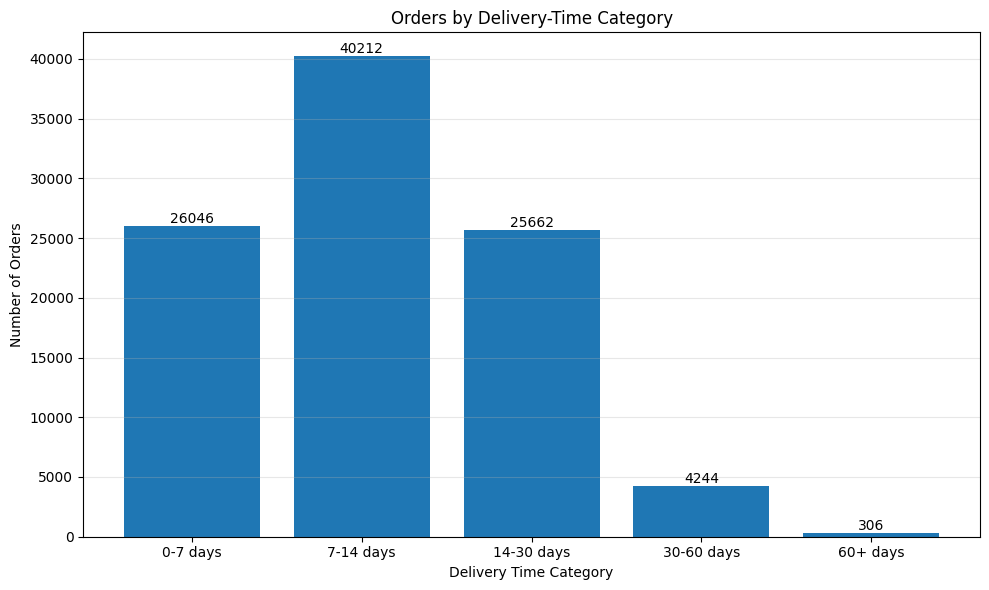

In [39]:
# Create a final dataset based on the non-negative delivery times
final_delivery = valid_delivery_time.copy()

print("Final delivery records:", len(final_delivery))
print("Minimum delivery time:", final_delivery["delivery_time"].min())
print("Maximum delivery time:", final_delivery["delivery_time"].max())

# Create delivery-time categories
final_delivery["delivery_category"] = pd.cut(
    final_delivery["delivery_time"],
    bins=[-1, 7, 14, 30, 60, float("inf")],
    labels=[
        "0-7 days",
        "7-14 days",
        "14-30 days",
        "30-60 days",
        "60+ days"
    ]
)

print(final_delivery["delivery_category"].value_counts().sort_index())

# Orders by Delivery-Time Category chart
import matplotlib.pyplot as plt

# Count orders in each delivery-time category
delivery_category_counts = (
    final_delivery["delivery_category"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))

plt.bar(
    delivery_category_counts.index,
    delivery_category_counts.values
)

plt.xlabel("Delivery Time Category")
plt.ylabel("Number of Orders")
plt.title("Orders by Delivery-Time Category")

plt.bar_label(plt.gca().containers[0])    # Get the current axes

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("orders_by_delivery_time_category.png", dpi=300)
plt.show()

**Delivery-Time Categories**

*   `final_delivery` was created from `valid_delivery_time`. It contains 96470 delivered orders, with delivery times from 0.53 to 209 days (purchase to customer).
*   Orders were grouped into five categories by delivery time: up to 7 days, 7-14 days, 14-30 days, 30-60 days and over 60 days.
*   26046 orders  were delivered within 7 days, and 40212 orders took 7-14 days.
*   25662 orders took 14-30 days, and 4550 orders took more than 30 days. The slowest group is small.
*   The bar chart shows how orders are spread across these categories. Most orders fall in the first two groups, and the number of orders drops as delivery time gets longer.

count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: days_late, dtype: float64
delivery_status
Early      88644
Late        6534
On time     1292
Name: count, dtype: int64
Promised (days): 24.0
Actual   (days): 10.217476851851853


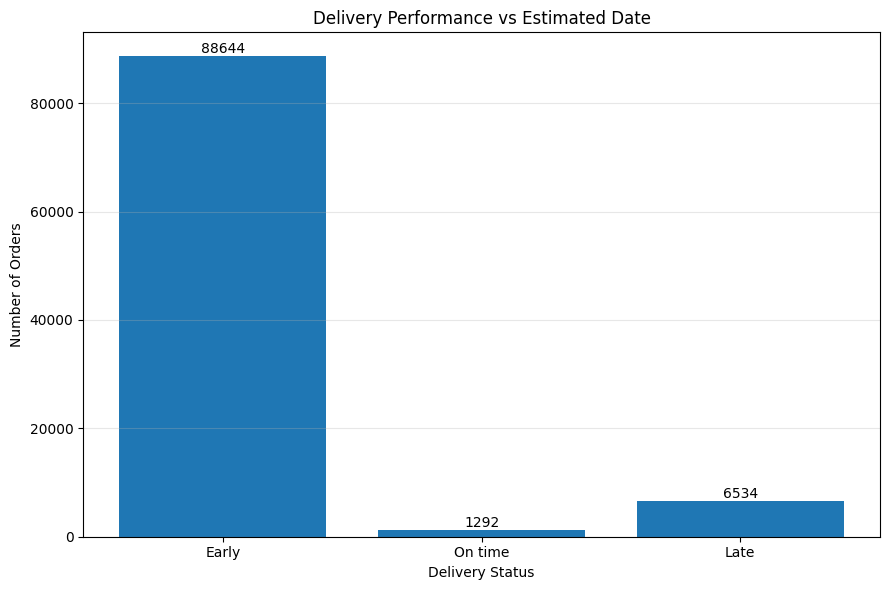

In [40]:
# Compare actual delivery time with estimated delivery time
final_delivery["days_late"] = (
    final_delivery["order_delivered_customer_date"].dt.normalize()
    - final_delivery["order_estimated_delivery_date"].dt.normalize()
).dt.days

print(final_delivery["days_late"].describe())

# Classify orders as early/on-time/late
final_delivery["delivery_status"] = pd.cut(
    final_delivery["days_late"],
    bins=[-float("inf"), -1, 0, float("inf")],
    labels=["Early", "On time", "Late"]
)

print(final_delivery["delivery_status"].value_counts())

# Delivery Performance vs Estimated Date, a bar chart showing Early, On time, and Late orders
import matplotlib.pyplot as plt

# Count orders by delivery status
delivery_performance = final_delivery["delivery_status"].value_counts()

# Keep the logical order
delivery_performance = delivery_performance.reindex(
    ["Early", "On time", "Late"]
)

# How long did Olist promise vs how long it really took?
final_delivery["estimated_days"] = (final_delivery["order_estimated_delivery_date"].dt.normalize()
                                    - final_delivery["order_purchase_timestamp"].dt.normalize()).dt.days

print("Promised (days):", final_delivery["estimated_days"].median())
print("Actual   (days):", final_delivery["delivery_time"].median())

plt.figure(figsize=(9, 6))

plt.bar(
    delivery_performance.index,
    delivery_performance.values
)

plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.title("Delivery Performance vs Estimated Date")

plt.bar_label(plt.gca().containers[0])    # Get Current Axes

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("delivery_performance_vs_estimated_date.png", dpi=300)
plt.show()

**Delivery Performance vs Estimated Date**

*   `days_late` was calculated as the actual delivery date minus the estimated delivery date, using **dates only** because the estimate has no time. A negative value means the order arrived early.
*   Orders were classified as **Early**, **On time** or **Late**. The comparison covers 96470 delivered orders.
*   88644 orders (91.9%) were delivered early, 1292 orders (1.3%) on time and 6534 orders (6.8%) late. On average, orders arrived ~12 days before the estimated date.
*   **Estimates are very conservative.** The median promised delivery time was 24 days, while the median actual delivery time was 10 days. A high early percentage therefore mostly shows that the estimates are padded. It does not by itself prove strong delivery performance.
*   The **late rate of 6.8%** is the better measure of performance, because it shows the orders where the customer's expectation was broken.
*   These results cover **delivered orders only**. Canceled, unavailable and undelivered orders are not included, so the true late rate is probably higher than shown here.
*   The bar chart compares the number of orders in each status. Early orders are by far the largest group.

count    6532.000000
mean       10.622321
std        14.646601
min         1.000000
25%         3.000000
50%         7.000000
75%        13.000000
max       188.000000
Name: days_late, dtype: float64
late_category
1-3 days      1869
4-7 days      1801
8-14 days     1478
15-30 days    1039
30+ days       345
Name: count, dtype: int64


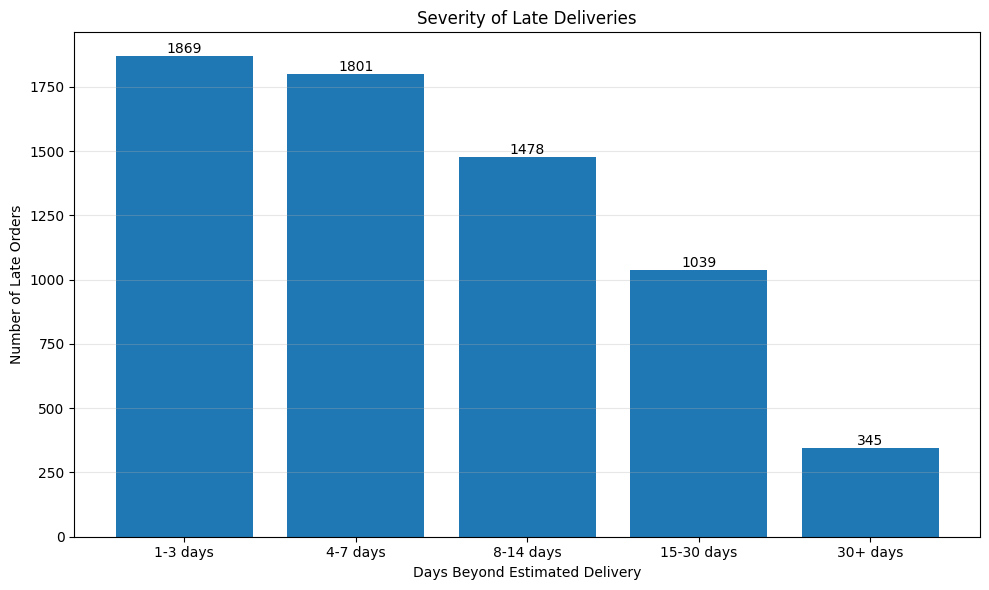

In [ ]:
# Examine how late the late orders actually were
late_orders = final_delivery[final_delivery["days_late"] > 0].copy()

print(late_orders["days_late"].describe())

# Analyse how many late orders fall into practical delay categories
late_orders["late_category"] = pd.cut(
    late_orders["days_late"],
    bins=[0, 3, 7, 14, 30, float("inf")],
    labels=[
        "1-3 days",
        "4-7 days",
        "8-14 days",
        "15-30 days",
        "30+ days"
    ])

print(late_orders["late_category"].value_counts().sort_index())

# Severity of Late Deliveries chart
import matplotlib.pyplot as plt

# Count late orders by severity
late_severity = late_orders["late_category"].value_counts().sort_index()

plt.figure(figsize=(10, 6))

plt.bar(
    late_severity.index,
    late_severity.values
)

plt.xlabel("Days Beyond Estimated Delivery")
plt.ylabel("Number of Late Orders")
plt.title("Severity of Late Deliveries")

plt.bar_label(plt.gca().containers[0])    # Get Current

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("late_delivery_severity.png", dpi=300)
plt.show()

**Severity of Late Deliveries**

*   Only orders that arrived **after** the estimated date were selected: 6532 late orders. The bar chart groups them by how many days they were late.
*   On average, late orders were 10 days late, and the median was 7 days. The mean is higher than the median because a few orders were very late.
*   1869 orders (28.6%) were 1-3 days late, which is the largest group. 1807 orders were 4-7 days late, 1478 were 8-14 days late and 1039 were 15-30 days late.
*   Only 345 orders (5.3%) were more than 30 days late, and the maximum delay was 188 days.
*   Most late orders were late by a small amount. A small group of long delays is what pulls the average up, and these are the orders most likely to upset customers.






                          orders  avg_delivery_time  median_delivery_time  \
order_purchase_timestamp                                                    
2016-09                        1          54.813194             54.813194   
2016-10                      265          19.600559             17.944282   
2016-12                        1           4.693021              4.693021   
2017-01                      750          12.647044             10.733646   
2017-02                     1653          13.168825             10.971204   
2017-03                     2546          12.951184             10.126487   
2017-04                     2303          14.917913             12.748623   
2017-05                     3545          11.322363              9.793333   
2017-06                     3135          12.011573             10.804907   
2017-07                     3872          11.592732             10.158073   
2017-08                     4193          11.147125              9.769815   

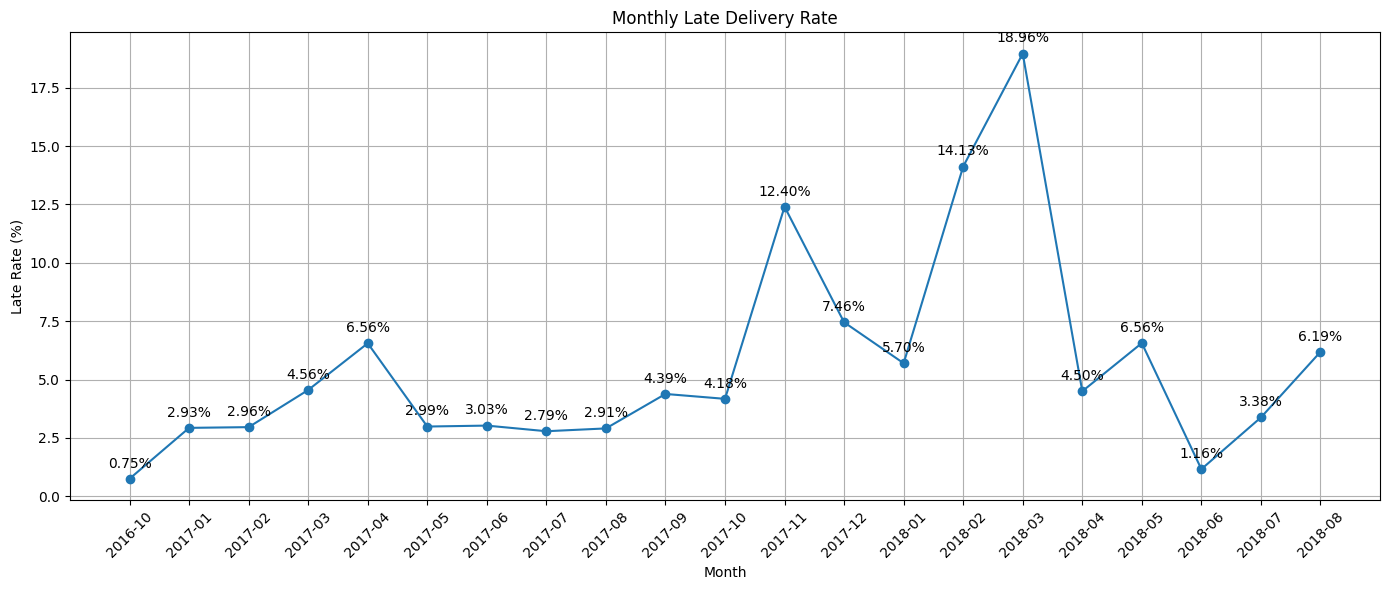

In [41]:
# Monthly delivery performance
monthly_delivery = (final_delivery
    .groupby(final_delivery["order_purchase_timestamp"].dt.to_period("M"))
    .agg(orders=("order_id", "count"),
         avg_delivery_time=("delivery_time", "mean"),
         median_delivery_time=("delivery_time", "median"),
         late_orders=("days_late", lambda x: (x > 0).sum())
    ))

monthly_delivery["late_rate"] = monthly_delivery["late_orders"] / monthly_delivery["orders"] * 100
print(monthly_delivery)

# Only plot months with at least 100 orders
monthly_plot = monthly_delivery[monthly_delivery["orders"] >= 100]

# Show the monthly late-rate trend
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_plot.index.astype(str),
    monthly_plot["late_rate"],
    marker="o"
)

# Add values above each point
for x, y in zip(monthly_plot.index.astype(str),monthly_plot["late_rate"]):
    plt.annotate(f"{y:.2f}%",(x, y),textcoords="offset points",xytext=(0, 8),ha="center")

plt.xlabel("Month")
plt.ylabel("Late Rate (%)")
plt.title("Monthly Late Delivery Rate")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig("monthly_late_rate.png", dpi=300)
plt.show()

**Monthly Late Delivery Rate (by Purchase Month)**

*   Orders were grouped by the month they were **purchased**, not the month they were delivered. Grouping by delivery month would put slow orders into later months and make those months look worse than they were.
*   For each month, the table shows the number of orders, the average and median delivery time, the number of late orders and the late rate.
*   Months with fewer than 100 orders were left out of the chart, because a rate based on a handful of orders is not reliable. The first and last months of the data are the most affected.








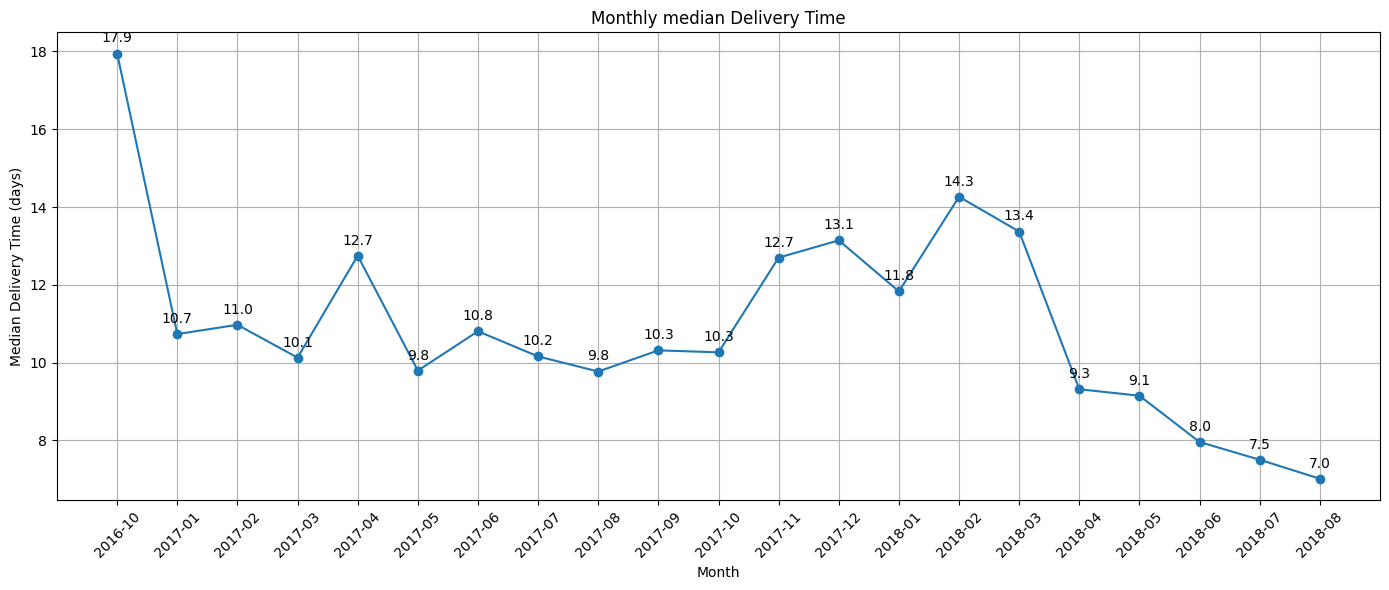

In [44]:
# Visualize the monthly trend
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_plot.index.astype(str),
    monthly_plot["median_delivery_time"],
    marker="o"
)

# Add values above each point
for x, y in zip(monthly_plot.index.astype(str), monthly_plot["median_delivery_time"]):
    plt.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center")

plt.xlabel("Month")
plt.ylabel("Median Delivery Time (days)")
plt.title("Monthly median Delivery Time")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig("monthly_median_delivery_time.png", dpi=300)
plt.show()

**Monthly Median Delivery Time (by Purchase Month)**

*   The line chart shows the **median** delivery time (purchase to customer) for each purchase month. The median is used instead of the average because a few very slow orders pull the average up.
*   Only months with at least 100 orders are plotted, so small months do not create misleading spikes.



In [45]:
# Join one review per order to the delivery data
merged = final_delivery.merge(reviews_one[["order_id", "review_score"]], on="order_id", how="left")

# Group orders by how late they were
merged["late_group"] = pd.cut(
    merged["days_late"],
    bins=[-1000, -1, 0, 3, 7, 14, 1000],
    labels=["Early", "On time", "1-3 late", "4-7 late", "8-14 late", "15+ late"]
)

# Average review score and number of orders in each group
print(merged.groupby("late_group", observed=True)["review_score"].agg(["count", "mean"]).round(2))

            count  mean
late_group             
Early       88163  4.29
On time      1280  4.03
1-3 late     1852  3.29
4-7 late     1748  2.10
8-14 late    1446  1.67
15+ late     1335  1.72


**Delivery Lateness vs Customer Review Score**

*   One review per order (`reviews_one`, the latest review) was joined to `final_delivery`, so no order is counted twice.
*   Orders were grouped by how late they were: Early, On time, 1-3 days late, 4-7 days late, 8-14 days late and 15+ days late. For each group, the table shows the number of reviews and the average review score.
*   Early orders have the highest average score, 4.29. On-time orders average 4.03.
*   The average score drops as lateness increases: 3.29 for 1-3 days late, 2.10 for 4-7 days, 1.67 for 8-14 days and 1.72 for 15+ days late.
*   This is an **association**, not proof that lateness is the only cause of low scores. Other factors, such as product quality, may also affect the score.
*   Business takeaway: reducing long delays (8+ days late) is likely to improve customer satisfaction more than making already-early orders faster.